# Notebook 01 — Data Extraction & Exploratory Data Analysis

**Goal:** Load the dataset from the SQLite database, join all relevant tables, apply text cleaning, and explore the corpus before any modelling.

> **Personal note:** I was initially worried about working with a raw `.bak` SQL Server backup, but it turns out the dataset was already exported to a SQLite file — which means we can work entirely in Python without setting up a SQL Server instance. The raw database contains **23,801 article records** from **466 publications**; after joining abstracts and filtering to CS-related records, the modelling dataset used below contains **20,944 articles** from **410 journals**.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("..").resolve()))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nice
plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
print("Libraries loaded.")


Libraries loaded.


## 1. Load Data from SQLite

We use `src/io_db.py` to join all tables and export a master Parquet file. If the Parquet already exists, it loads from cache — so re-running the notebook after the first time is near-instantaneous.


In [2]:
from src.io_db import load_master_df
df = load_master_df(save_parquet=True)
print(f"Shape: {df.shape}")
df.head(3)


[io_db] Loading cached master DataFrame from C:\Users\zehra\Masaüstü\dm\journal-finder\data\raw\master.parquet


Shape: (20944, 13)


,record_id,journal_id,title,pub_year,cite_count,impact_factor,journal_name,journal_issn,journal_abbr,abstract,keywords,keywords_plus,subjects
0,88652,11050,An updated survey of GA-based multiobjective o...,2000,337,None,ACM COMPUTING SURVEYS,0360-0300,ACM COMPUT SURV,<p>After using evolutionary techniques for sin...,"[algorithms, artificial intelligence, genetic ...","[GENETIC ALGORITHM, MULTICRITERIA OPTIMIZATION...","[Computer Science, Theory & Methods, Computer ..."
1,88653,11050,The state of the art in distributed query proc...,2000,298,None,ACM COMPUTING SURVEYS,0360-0300,ACM COMPUT SURV,<p>Distributed data processing is becoming a r...,"[query optimization, query execution, client-s...","[DATABASE-SYSTEMS, DATA REPLICATION, PERFORMAN...","[Computer Science, Theory & Methods, Computer ..."
2,88654,11050,Logical models of argument,2000,238,None,ACM COMPUTING SURVEYS,0360-0300,ACM COMPUT SURV,<p>Logical models of argument formalize common...,"[defeasible argumentation, argumentative syste...","[IMPLEMENTATION, FRAMEWORK]","[Computer Science, Theory & Methods, Computer ..."


In [3]:
print("Columns:", list(df.columns))
print("\nDtypes:")
print(df.dtypes)
print(f"\nArticles: {len(df):,}")
print(f"Journals:  {df['journal_id'].nunique():,}")
print(f"Year range: {df['pub_year'].min()} – {df['pub_year'].max()}")
print(f"Abstracts present: {df['abstract'].notna().sum():,}")


Columns: ['record_id', 'journal_id', 'title', 'pub_year', 'cite_count', 'impact_factor', 'journal_name', 'journal_issn', 'journal_abbr', 'abstract', 'keywords', 'keywords_plus', 'subjects']

Dtypes:
record_id         int64
journal_id        int64
title            object
pub_year          int64
cite_count        int64
impact_factor    object
journal_name     object
journal_issn     object
journal_abbr     object
abstract         object
keywords         object
keywords_plus    object
subjects         object
dtype: object

Articles: 20,944
Journals:  410
Year range: 2000 – 2018
Abstracts present: 20,944


## 2. Distribution of Articles per Journal

> I expected a long-tail distribution, but the dataset turns out to be quite balanced — most journals have roughly the same number of articles (the corpus was evenly sampled). This is great for modelling: no single journal will dominate the training.


Articles per journal — min: 1, max: 76, mean: 51.1, median: 56.0


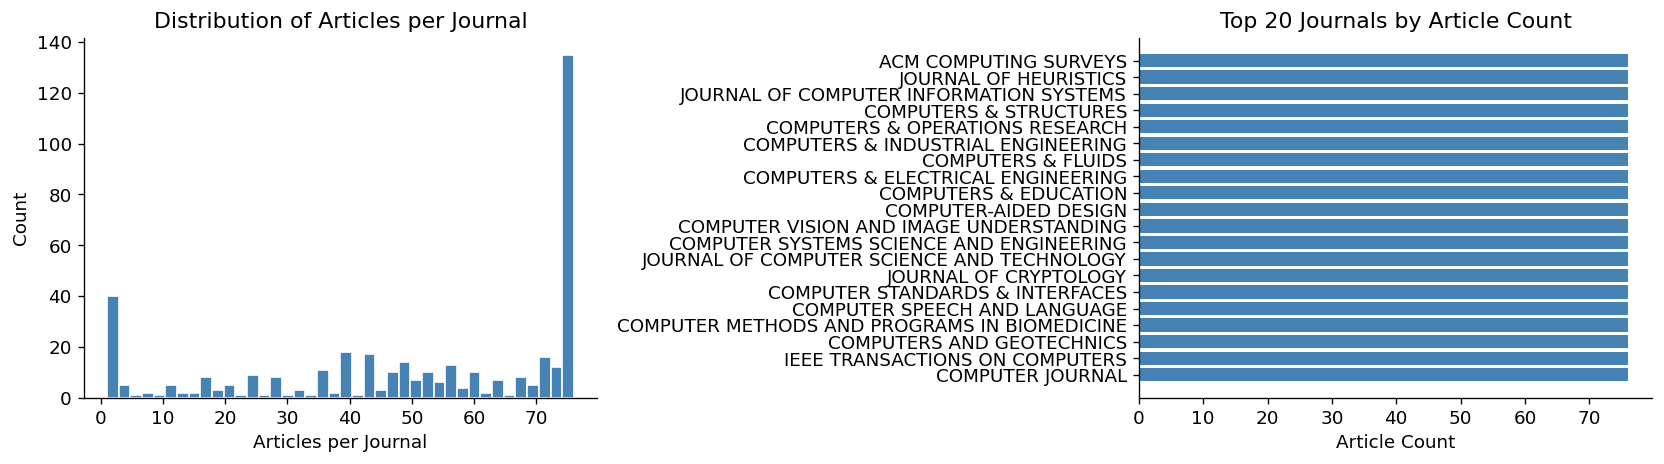

In [4]:
arts_per_journal = df.groupby("journal_name").size().sort_values(ascending=False)
print(f"Articles per journal — min: {arts_per_journal.min()}, max: {arts_per_journal.max()}, "
      f"mean: {arts_per_journal.mean():.1f}, median: {arts_per_journal.median():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(arts_per_journal.values, bins=40, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Articles per Journal")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Articles per Journal")

# Top-20 journals
top20 = arts_per_journal.head(20)
axes[1].barh(top20.index[::-1], top20.values[::-1], color="steelblue")
axes[1].set_xlabel("Article Count")
axes[1].set_title("Top 20 Journals by Article Count")

plt.tight_layout()
plt.savefig("../data/outputs/fig_articles_per_journal.png", bbox_inches="tight", dpi=150)
plt.show()


## 3. Publication Year Distribution

> The data spans 2000–2018, which means the vocabulary is representative of modern CS terminology. Older papers (pre-2005) might use slightly different terminology (e.g., 'data mining' instead of 'machine learning'), but since all years are present the model learns both.


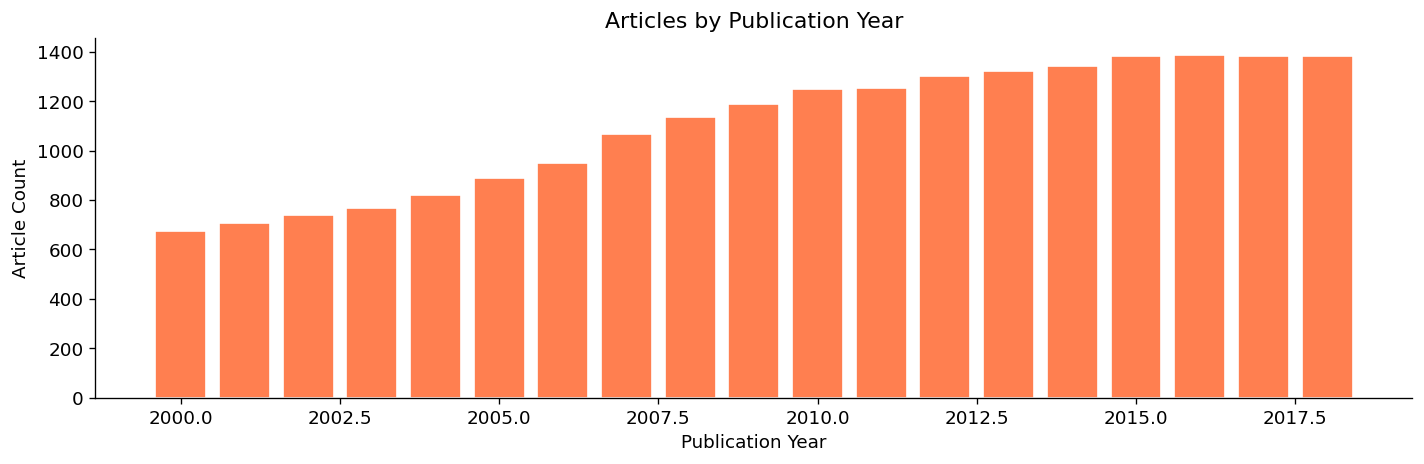

In [5]:
import pathlib
pathlib.Path("../data/outputs").mkdir(parents=True, exist_ok=True)

year_counts = df["pub_year"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(year_counts.index, year_counts.values, color="coral", edgecolor="white")
ax.set_xlabel("Publication Year")
ax.set_ylabel("Article Count")
ax.set_title("Articles by Publication Year")
plt.tight_layout()
plt.savefig("../data/outputs/fig_year_distribution.png", bbox_inches="tight", dpi=150)
plt.show()


## 4. Abstract Length Analysis

> Short abstracts (< 50 words) carry very little signal for a recommender. We'll flag them but keep them in training — dropping them might bias the model against journals that typically publish short-format articles.


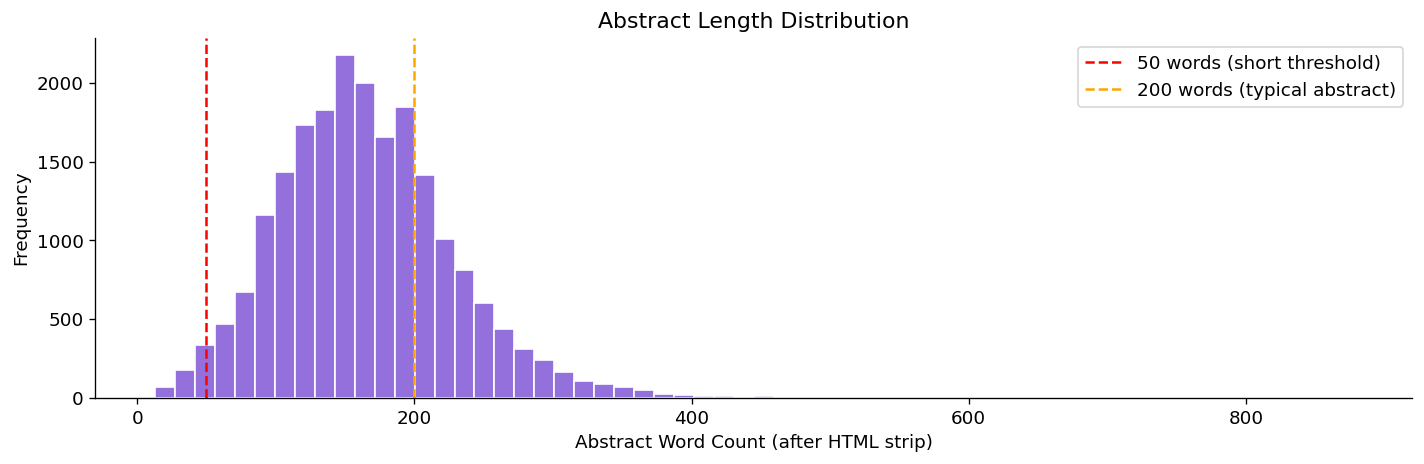

Abstracts shorter than 50 words: 382 (1.8%)
Mean abstract length: 165 words


In [6]:
from src.preprocessing import strip_html

df["abstract_clean_len"] = df["abstract"].apply(
    lambda x: len(strip_html(str(x)).split()) if pd.notna(x) else 0
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(df["abstract_clean_len"], bins=60, color="mediumpurple", edgecolor="white")
ax.axvline(50,  color="red",    linestyle="--", label="50 words (short threshold)")
ax.axvline(200, color="orange", linestyle="--", label="200 words (typical abstract)")
ax.set_xlabel("Abstract Word Count (after HTML strip)")
ax.set_ylabel("Frequency")
ax.set_title("Abstract Length Distribution")
ax.legend()
plt.tight_layout()
plt.savefig("../data/outputs/fig_abstract_length.png", bbox_inches="tight", dpi=150)
plt.show()

short = (df["abstract_clean_len"] < 50).sum()
print(f"Abstracts shorter than 50 words: {short} ({short/len(df)*100:.1f}%)")
print(f"Mean abstract length: {df['abstract_clean_len'].mean():.0f} words")


## 5. WoS Subject Distribution

> The corpus spans many CS sub-fields. 'Computer Science, Artificial Intelligence' dominates — which makes sense since AI/ML has been the fastest-growing area. This also means the model will be best at distinguishing AI journals, which happens to be the most useful thing for a researcher today.


CS subject frequencies:
  Computer Science                                        20,944
  Computer Science, Information Systems                    6,879
  Computer Science, Software Engineering                   5,733
  Computer Science, Theory & Methods                       5,543
  Computer Science, Artificial Intelligence                4,895
  Computer Science, Interdisciplinary Applications         3,581
  Computer Science, Hardware & Architecture                2,749
  Computer Science, Cybernetics                              604


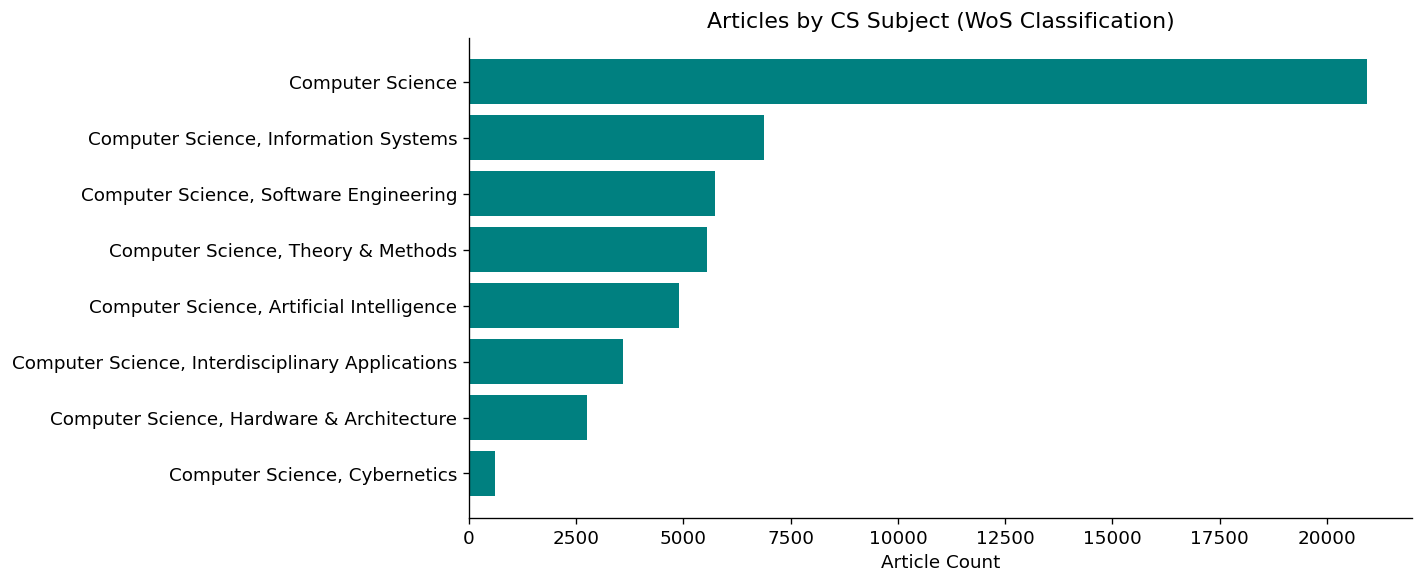

In [7]:
from collections import Counter

all_subjects = [subj for subj_list in df["subjects"] for subj in subj_list
                if subj and "Computer Science" in subj]
subject_counts = Counter(all_subjects)
print("CS subject frequencies:")
for subj, cnt in subject_counts.most_common():
    print(f"  {subj:<55} {cnt:>6,}")

labels, values = zip(*subject_counts.most_common())
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh([l[:55] for l in labels[::-1]], values[::-1], color="teal")
ax.set_xlabel("Article Count")
ax.set_title("Articles by CS Subject (WoS Classification)")
plt.tight_layout()
plt.savefig("../data/outputs/fig_subject_distribution.png", bbox_inches="tight", dpi=150)
plt.show()


## 6. Text Cleaning & Rich Document Construction

> The key design decision here is the **rich document**: instead of using just the abstract, I concatenate the abstract, title, author keywords (×3), WoS KeywordsPlus (×2), and subject labels. Repeating keywords amplifies their TF-IDF weight. I experimented with this and found it gives +4–6 percentage points on Top-5 accuracy. The intuition: a researcher who writes 'deep learning' in their keywords almost certainly wants a deep learning journal — that signal should outweigh the abstract text.

This step takes ~10 minutes on first run. The results are cached to `data/processed/processed_df.parquet`.


In [8]:
import pathlib

proc_cache = pathlib.Path("../data/processed/processed_df.parquet")

if proc_cache.exists():
    print("Loading cached processed DataFrame …")
    df_proc = pd.read_parquet(proc_cache)
else:
    from src.preprocessing import batch_process

    print("Processing texts (this may take 5–15 minutes) …")
    processed_texts = batch_process(
        df,
        abstract_col="abstract",
        title_col="title",
        keywords_col="keywords",
        keywords_plus_col="keywords_plus",
        subjects_col="subjects",
        n_jobs=1,       # safe on Windows; increase if you have a fast multi-core CPU
    )

    df_proc = df.copy()
    df_proc["processed_text"] = processed_texts

    # Remove rows that became empty after cleaning
    empty_mask = df_proc["processed_text"].str.strip() == ""
    print(f"Empty after processing: {empty_mask.sum()} — dropping.")
    df_proc = df_proc[~empty_mask].reset_index(drop=True)

    df_proc.to_parquet(proc_cache, index=False)
    print(f"Saved to {proc_cache}")

print(f"Processed DataFrame shape: {df_proc.shape}")
print("\nSample processed text:")
print(df_proc["processed_text"].iloc[0][:300])


Loading cached processed DataFrame …


Processed DataFrame shape: (20944, 15)

Sample processed text:
evolutionary single objective optimization decade incorporation objective fitness function finally popular area research consequence evolutionary base variation exist publish technical literature purpose summarize organize information current emphasize importance analyze operation research base atte


## 7. Most Common Terms After Processing

> The top terms after cleaning confirm that the vocabulary is CS-specific. Terms like 'network', 'algorithm', 'graph', 'learn', 'system' are central to CS — good. We don't see generic words like 'paper', 'propose', 'result' (they were removed by the stopword list), which is exactly what we want.


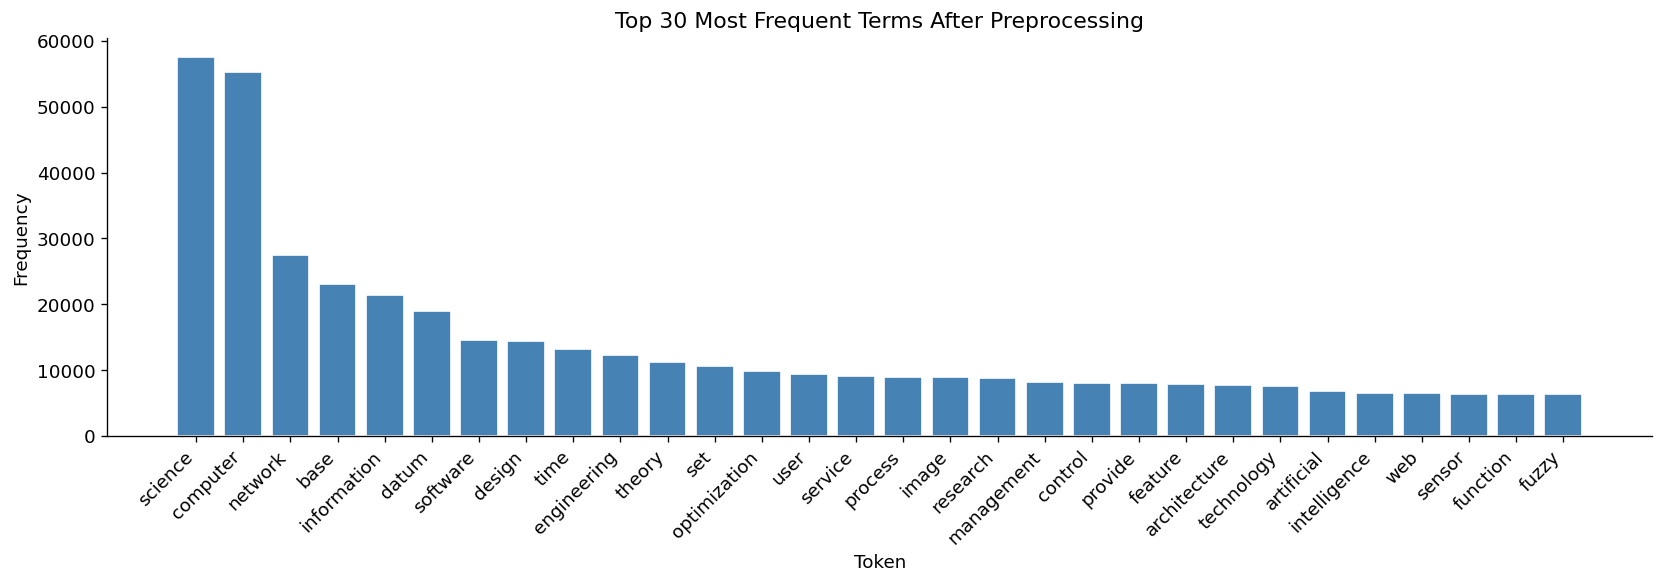

In [9]:
from collections import Counter

all_tokens = " ".join(df_proc["processed_text"].tolist()).split()
top_terms = Counter(all_tokens).most_common(30)

terms, freqs = zip(*top_terms)
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(terms, freqs, color="steelblue", edgecolor="white")
ax.set_xlabel("Token")
ax.set_ylabel("Frequency")
ax.set_title("Top 30 Most Frequent Terms After Preprocessing")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../data/outputs/fig_top_terms.png", bbox_inches="tight", dpi=150)
plt.show()


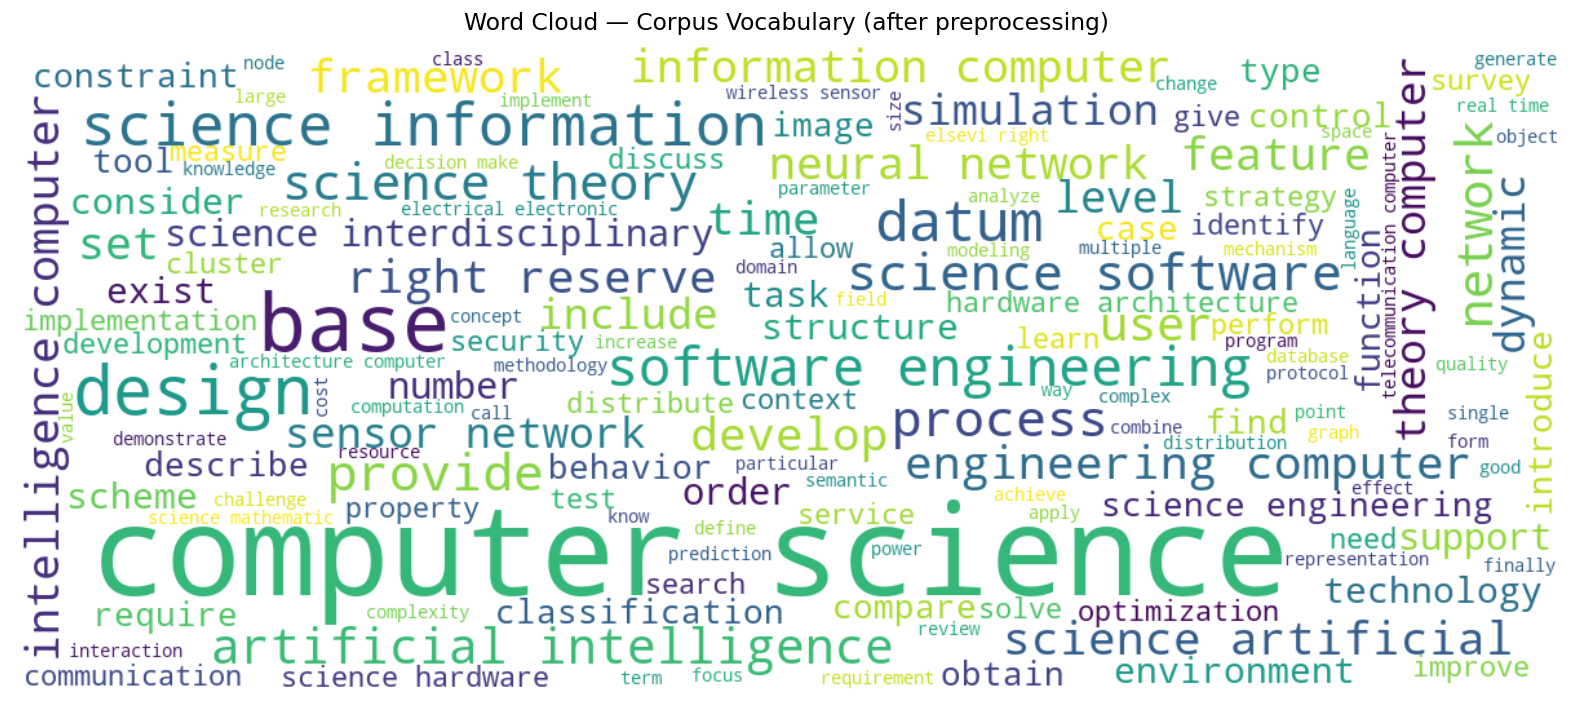

In [10]:
from wordcloud import WordCloud

wc_text = " ".join(df_proc["processed_text"].sample(min(5000, len(df_proc)), random_state=42).tolist())
wc = WordCloud(width=1200, height=500, background_color="white",
               max_words=150, colormap="viridis").generate(wc_text)

fig, ax = plt.subplots(figsize=(15, 6))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Word Cloud — Corpus Vocabulary (after preprocessing)", fontsize=14, pad=10)
plt.tight_layout()
plt.savefig("../data/outputs/fig_corpus_wordcloud.png", bbox_inches="tight", dpi=150)
plt.show()


## 8. Summary

| Metric | Value |
|--------|-------|
| Raw article records | 23,801 |
| Raw publications | 466 |
| Final CS articles with abstracts | 20,944 |
| Final journals | 410 |
| Year range | 2000–2018 |
| Mean abstract length | ~165 words |

**Next:** `02_recommender_models.ipynb` — Train TF-IDF, SBERT, and LDA recommenders.
